Tadas Riksas 2312087 convnext_large Zebra Banana Parachute

### 1 individuali užduotis
#### Tvarka

**Pirmos užduoties atsiskaitymo maksimaliam balui terminas yra vasario 24 d.**  
(Planuokite laiką, nepasilikite užduočių paskutinėms savaitėms, 
pretenduoti į maksimalų balą galima tą savaitę, kada pradėta atsiskaityti.)  
Atsiskaitymo eilė ir savaitė kada prasideda atsiskaitymas yra fiksuojama 
pagal el. laiško su siunčiama atsiskaitymui programa laiką.
Atsiskaitymo eilė ir savaitė, kada prasideda atsiskaitymas, yra fiksuojama 
pagal užduoties įkėlimo į VMA aplinką laiką.
**Kiekvienos užduoties sprendimas turi būti 
realizuotas aiškiai pavadintais kintamaisiais ir dokumentuotas.**  
Užduoties pradžioje turi būti informacija su autoriaus vardu, pavarde ir LSP numeriu ir variantu.
Variantas - pasirinktas iš anksto apmokytas modelis ir klasių rinkinys.
Kiekvienas sprendimas vertinamas atsižvelgiant į prie užduoties vertinimo 
nurodytą balų skaičių. 
Atsiskaitymo metu pratybų dėstytojai gali prašyti pakomentuoti ar
pakeisti programą.  
**Maksimalus užduoties įvertinimas (be papildomų balų) - 1 balas.**  
Užduotis gali būti tikslinama semestro eigoje. Užduoties versija rašoma dokumento viršuje, o potencialūs pakeitimai pažymėti.

#### Vertinimas

Už pirmą užduotį galima surinkti be papildomų balų iki 1 balo, su papildomais balais iki 1,2 balo.

Vertinimo dedamosios:

|   |  Reikalavimas | maksimalus įvertinimas  |
|---|---|---|
| $A$ | Korektiškas programos veikimas, programos komentavimas ir atsakymai į klausimus, programos modifikavimas atsiskaitymo metu, |  1,0 |  
| $P_1$  | Papildomas balas: atsiskaitymas anksčiau  |  0,2  |  
| $B$ | **Viso** |  1,2 |



Galutinis užduoties vertinimo balas formuojamas:

$$
B = A + P_1 
$$

Atsiskaitymo savaitės papildomas balas $P_1$:



| Savaitė  |  Vasario 10 d. | Vasario 17 d.   | Vasario 24 d.  | Kovo 3 d.  |
|---|---|---|---|---|
| Papildomas/baudos balas  |  0,2 |  0,2 | 0  | -0,5  |


Įkeliant programą 5 sav. lieka pusė maksimalaus įvertinimo - 0,5 balo. 6-16 sav. įkelti 1 užduoties nebegalima.

#### Užduotis

Pirma užduotis reikalaus realizuoti:
* efektyvią duomenų nuskaitymo programą su pasirinku egzistuojančiu iš anksto apmokytu (angl. _pre-trained_) vaizdų klasifikavimo modeliu,
* paskaičiuoti tikslumo, precizijos, atkūrimo ir F1 statistikas pasirinktiems 1000 paveikslėlių iš [OpenImages](https://storage.googleapis.com/openimages/web/index.html),
* realizuoti slenkstinės reikšmės (angl. _threshold_) keitimą, įgalinant klasifikuoti vaizdus kiekvienai užduotai klasei keičiant $T \in [0,1]$. Statistikos turi persiskaičiuoti po slenkstinės reikšmės pakeitimo.

Studentai patys savo nuožiūra pasirenka tris klases, kurioms skaičiuos statistikas.


Atsiskaitinėjant pratybų dėstytojas atsiųs testinių vaizdų, su kuriais turėsite pademonstruoti, kaip veikia jūsų panaudotas modelis.

Atsiskaitymo metu turėsite gebėti paaiškinti, kaip realizuota jūsų užduoties duomenų nuskaitymo klasė (Dataset).
Programinės įrangos sprendimą galite naudoti savo nuožiūra.


Reikalingos sąvokos: rinkinys (angl. _batch_), duomenų aibės klasė (angl. _Dataset_), duomenų paruošėjas (angl. _DataLoader_), darbininkai (angl. _workers_), duomenų išankstinis išsaugojimas ir kešavimas (angl. _pre-fetching, caching_), duomenų nuskaitymo paralelizavimas, duomenų transformacijų (augmentacijų) paralelizavimas.


In [ ]:
pip install --user torch torchvision scikit-image numpy matplotlib==3.10.8 pandas openimages

In [28]:
import os
import torch
import pandas as pd
from skimage import io, transform
from skimage.color import gray2rgb
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from openimages.download import download_dataset
import torchvision.models as models
import glob

In [ ]:
data_dir = "./project/data/"

# TODO - increase in production
number_of_samples = 334
classes = ["Zebra", "Banana", "Parachute"]
mappings = [340, 954, 701]

if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    
print("Downloading data...")
download_dataset(
    data_dir,
    classes,
    limit=number_of_samples,
)

In [134]:
def read_img(file_name):
    img = io.imread(file_name)
    if img.ndim == 2:
        img = gray2rgb(img)
    if img.shape[2] == 4:
        img = img[:, :, :3]
    img = resize(img, (380, 380), anti_aliasing=True).astype(np.float32)
    img = torch.tensor(img)
    img = img.permute(2, 0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = (img - mean) / std
    return img

In [135]:
class MyImages(Dataset):
    def __init__(self, path):
        self.path = path
        self.images = os.listdir(path)
        
        self.class1_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[0].lower()))
        self.class2_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[1].lower()))
        self.class3_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[2].lower()))
        
        # include only the number of samples specified
        self.class1_files = self.class1_files[:number_of_samples]
        self.class2_files = self.class2_files[:number_of_samples]
        self.class3_files = self.class3_files[:number_of_samples]
        
        self.class1 = len(self.class1_files)
        self.class2 = len(self.class2_files)
        self.class3 = len(self.class3_files)
        
        self.files = self.class1_files + self.class2_files + self.class3_files
        
        self.labels = [mappings[0]] * self.class1 + [mappings[1]] * self.class2 + [mappings[2]] * self.class3
        
        self.order = [x for x in np.random.permutation(len(self.files))]
        self.files = [self.files[i] for i in self.order]
        self.labels = [self.labels[i] for i in self.order]
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        img = read_img(self.files[idx])
        label = self.labels[idx]
        return img, label
    
dataset = MyImages(data_dir)
dataloader = DataLoader(dataset, 
                        batch_size=256, 
                        shuffle=True,
                        num_workers=4,
                        pin_memory=True,
                        prefetch_factor=2)

In [136]:
model = models.convnext_large(pretrained=True)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_predictions = []
all_labels = []
with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.nn.functional.sigmoid(outputs)
        all_predictions.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

print("Predictions shape:", np.concatenate(all_predictions).shape)
print("Labels shape:", np.concatenate(all_labels).shape)

Predictions shape: (902, 1000)
Labels shape: (902,)


In [137]:

def classify_with_threshold(predictions, true_labels, class_idx: int, threshold=0.5):
    """
    Classify samples based on threshold for a specific class
    # """
    class_probs = predictions[:, class_idx]
    predicted = (class_probs >= threshold).astype(int)
    true = (true_labels == class_idx).astype(int)
    
    # Calculate metrics
    tp = np.sum((predicted == 1) & (true == 1))
    fp = np.sum((predicted == 1) & (true == 0))
    fn = np.sum((predicted == 0) & (true == 1))
    tn = np.sum((predicted == 0) & (true == 0))
    
    accuracy = (tp + tn) / len(true) if len(true) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [144]:

all_predictions_concat = np.concatenate(all_predictions)
all_labels_concat = np.concatenate(all_labels)
T_list = np.concatenate([
    np.linspace(0.05, 0.7, 15),  
    np.linspace(0.7, 1, 15),
])
results = {class_name: [] for class_name in classes}

for j in range(3):
    for T in T_list:
        metrics = classify_with_threshold(
            all_predictions_concat, 
            all_labels_concat, 
            mappings[j],  # class_idx 
            threshold=T
        )
        results[classes[j]].append(metrics['f1'])
    
    # Find optimal threshold
    idx = np.argmax(results[classes[j]])
    print(f"Optimal T={T_list[idx]:.2f} for {classes[j]} (F1={results[classes[j]][idx]:.3f})")

Optimal T=0.87 for Zebra (F1=0.996)
Optimal T=0.76 for Banana (F1=0.994)
Optimal T=0.94 for Parachute (F1=0.997)


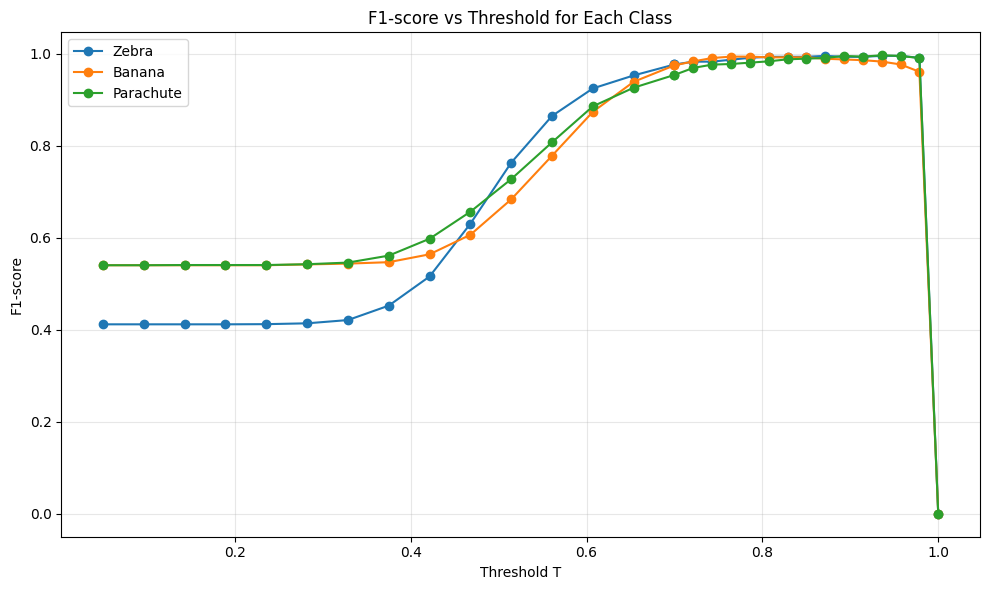

In [145]:
plt.figure(figsize=(10, 6))

for class_name in classes:
    plt.plot(T_list, results[class_name], marker='o', label=class_name)

plt.xlabel("Threshold T")
plt.ylabel("F1-score")
plt.title("F1-score vs Threshold for Each Class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [146]:

print(all_labels_concat[:10])
print(all_predictions_concat[:, mappings][:10])
print([np.max(all_predictions_concat[i]) for i in range(10)])

# select classes with max probability
for i in range(10):
    predicted_class_idx = np.argmax(all_predictions_concat[i])
    print(predicted_class_idx)

[701 340 701 954 340 954 701 701 954 340]
[[0.4337214  0.3789927  0.996743  ]
 [0.9989617  0.54231197 0.6106306 ]
 [0.33819425 0.65756637 0.9997185 ]
 [0.5123443  0.99975353 0.51788026]
 [0.9994677  0.4152312  0.45171526]
 [0.4951443  0.9648616  0.5082888 ]
 [0.4616597  0.57067424 0.99977356]
 [0.4279531  0.4809431  0.99711514]
 [0.3893777  0.99939084 0.43576065]
 [0.99974483 0.4473953  0.37129542]]
[np.float32(0.9976273), np.float32(0.9989617), np.float32(0.9997185), np.float32(0.99975353), np.float32(0.9994677), np.float32(0.9998041), np.float32(0.99977356), np.float32(0.99711514), np.float32(0.99939084), np.float32(0.99974483)]
797
340
701
954
340
582
701
701
954
340
